In [ ]:
%pip install -r ./../stellar_classification/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
import os
import gc
import pandas as pd
import matplotlib.pyplot as plt
import numpy

# Add the package root to sys.path so we can import stellar_classification
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'stellar_classification')))

import stellar_classification as sc

# Enable garbage collection
gc.enable()
gc.collect()

from stellar_classification.utils.seeding import set_seed

SEED = 42

set_seed(SEED)

/home/ettore/anaconda3/envs/comp_astro/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load dataset
data_path = './star_classification.csv'
star = pd.read_csv(data_path)

print("First few rows:")
display(star.head())

print("\nData Info:")
star.info()

print("\nNull Values:")
print(star.isnull().sum())

print("\nClass Distribution:")
print(star["class"].value_counts(normalize=True) * 100)

# -------- Color indexes ----------
star["u_g"] = star["u"] - star["g"]
star["g_r"] = star["g"] - star["r"]
star["r_i"] = star["r"] - star["i"]
star["i_z"] = star["i"] - star["z"]

display(star.head())


First few rows:


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842



Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  str    
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7)

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,...,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,u_g,g_r,r_i,i_z
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,...,6.543777e+18,GALAXY,0.634794,5812,56354,171,1.60352,1.88029,1.22928,0.37202
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,...,1.176014e+19,GALAXY,0.779136,10445,58158,427,1.94571,0.24744,1.41632,-0.44615
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,...,5.152200e+18,GALAXY,0.644195,4576,55592,299,2.59918,2.05413,1.26119,0.40030
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,...,1.030107e+19,GALAXY,0.932346,9149,58039,775,-1.63974,2.16494,1.10708,1.25444
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,...,6.891865e+18,GALAXY,0.116123,6121,56187,842,1.85690,1.08281,0.52036,0.43250


In [3]:
# Preprocessing: Apply outlier removal, splits, standardization, and SMOTE
(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    label_encoder,
    scaler,
    feature_names,
    pca,
) = sc.prepare_splits(
    star,
    target_col='class',
    test_size=0.2,
    val_ratio=0.25,
    random_state=42,
    apply_outlier_removal=True
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

         obj_ID       alpha      delta         u        g         r         i  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573   

          z  run_ID  rerun_ID  ...   spec_obj_ID  class  redshift  plate  \
0  18.79371    3606       301  ...  6.543777e+18      0  0.634794   5812   

     MJD  fiber_ID      u_g      g_r      r_i      i_z  
0  56354       171  1.60352  1.88029  1.22928  0.37202  

[1 rows x 22 columns]
        alpha      delta         u        g         r         i         z  \
0  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573  18.79371   

   class  plate    MJD      u_g      g_r      r_i      i_z  
0      0   5812  56354  1.60352  1.88029  1.22928  0.37202  
Outliers removed: 8,715 rows  (91,285 remain)
X_train shape: (97032, 13)
X_val shape: (18257, 13)
X_test shape: (18257, 13)


In [4]:
train_loader, val_loader, test_loader = sc.to_dataloaders(
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    batch_size=64
)

print("DataLoaders created.")

DataLoaders created.


In [5]:
# ============================================================
# Neural Network setup
# ============================================================

input_size = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print("Input size:", input_size)
print("Number of classes:", num_classes)

Input size: 13
Number of classes: 3


In [6]:
# ============================================================
# Import experiment runner
# ============================================================

from stellar_classification.experiments.nn_runner import run_experiments

In [7]:
# ============================================================
# Run Neural Network Experiments
# ============================================================

results_df = run_experiments(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,

    input_size=input_size,
    num_classes=num_classes,

    model_types=[
        "SimpleNN",
        "MediumNN",
        "ComplexNN",
    ],

    learning_rates=[
        0.01,
        0.001,
        0.0001,
    ],

    epochs=4,
)


Training SimpleNN | lr=0.01
Epoch 1/4 | loss=0.4343 | train_acc=83.65% | val_acc=86.12%
Epoch 2/4 | loss=0.3909 | train_acc=85.27% | val_acc=84.11%
Epoch 3/4 | loss=0.3734 | train_acc=85.91% | val_acc=87.71%
Epoch 4/4 | loss=0.3669 | train_acc=86.21% | val_acc=88.40%
✔ Done: SimpleNN | lr=0.01 | loss=0.3669 | train_acc=86.48% | val_acc=88.40% | val_precision=0.8525 | val_recall=0.8560 | val_f1=0.8536

Training SimpleNN | lr=0.001
Epoch 1/4 | loss=0.4895 | train_acc=81.77% | val_acc=85.36%
Epoch 2/4 | loss=0.4147 | train_acc=84.58% | val_acc=85.85%
Epoch 3/4 | loss=0.3933 | train_acc=85.33% | val_acc=86.44%
Epoch 4/4 | loss=0.3796 | train_acc=85.75% | val_acc=87.14%
✔ Done: SimpleNN | lr=0.001 | loss=0.3796 | train_acc=86.03% | val_acc=87.14% | val_precision=0.8337 | val_recall=0.8506 | val_f1=0.8416

Training SimpleNN | lr=0.0001
Epoch 1/4 | loss=0.7031 | train_acc=72.16% | val_acc=79.68%
Epoch 2/4 | loss=0.5444 | train_acc=79.63% | val_acc=83.18%
Epoch 3/4 | loss=0.4919 | train_acc=8

In [8]:
# ============================================================
# Results
# ============================================================

display(results_df)

,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1,history
0,SimpleNN,0.0100,SimpleNN(\n (net): Sequential(\n (0): Line...,0.366887,86.213826,88.404448,86.480749,0.865503,0.864807,0.864172,88.404448,0.852485,0.855969,0.853570,88.453744,0.853156,0.856129,0.854227,"{'train_loss': [0.4342873623654806, 0.39091164..."
7,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.298893,88.651167,88.053897,88.777929,0.887959,0.887779,0.887793,88.053897,0.840788,0.868729,0.853320,88.552336,0.846519,0.871560,0.857910,"{'train_loss': [0.39170132531252205, 0.3335985..."
8,ComplexNN,0.0001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.332232,87.392819,88.108671,87.506184,0.875627,0.875062,0.874715,88.108671,0.844670,0.861827,0.851700,88.754998,0.852671,0.868399,0.859167,"{'train_loss': [0.4610169898662114, 0.36464433..."
3,MediumNN,0.0100,MediumNN(\n (net): Sequential(\n (0): Line...,0.326803,87.621609,88.026510,87.244414,0.873072,0.872444,0.871992,88.026510,0.847742,0.855836,0.850913,88.475653,0.853148,0.860728,0.856160,"{'train_loss': [0.40123721201834744, 0.3530729..."
4,MediumNN,0.0010,MediumNN(\n (net): Sequential(\n (0): Line...,0.329224,87.378391,87.675960,87.225864,0.874423,0.872259,0.872100,87.675960,0.839630,0.860945,0.848805,87.949827,0.842269,0.863075,0.851164,"{'train_loss': [0.4269672919926709, 0.35829767..."
6,ComplexNN,0.0100,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.337891,87.299035,87.604754,87.615426,0.879207,0.876154,0.875805,87.604754,0.839646,0.859450,0.846231,88.256559,0.847216,0.864837,0.853146,"{'train_loss': [0.41888028276186673, 0.3647593..."
1,SimpleNN,0.0010,SimpleNN(\n (net): Sequential(\n (0): Line...,0.379583,85.754184,87.144657,86.025229,0.860702,0.860252,0.859945,87.144657,0.833688,0.850586,0.841576,87.643096,0.838598,0.855540,0.846494,"{'train_loss': [0.48947171930741856, 0.4146918..."
5,MediumNN,0.0001,MediumNN(\n (net): Sequential(\n (0): Line...,0.397620,85.014222,86.235417,85.216217,0.852839,0.852162,0.851494,86.235417,0.823191,0.840936,0.830187,86.410692,0.824481,0.842915,0.832110,"{'train_loss': [0.6110303141643283, 0.44271513..."
2,SimpleNN,0.0001,SimpleNN(\n (net): Sequential(\n (0): Line...,0.467782,82.973658,84.592211,83.182868,0.831740,0.831829,0.831169,84.592211,0.803569,0.826386,0.813554,84.685326,0.804121,0.826380,0.814074,"{'train_loss': [0.7030930384924794, 0.54439077..."


In [9]:
from stellar_classification.visualization.nn_plots import plot_training_history

In [10]:
best_simple = results_df[results_df["model"] == "SimpleNN"].iloc[0]
best_medium = results_df[results_df["model"] == "MediumNN"].iloc[0]
best_complex = results_df[results_df["model"] == "ComplexNN"].iloc[0]

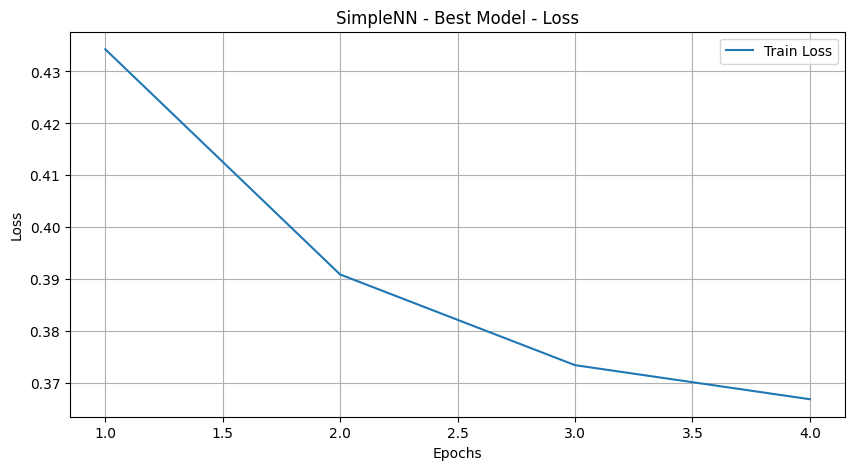

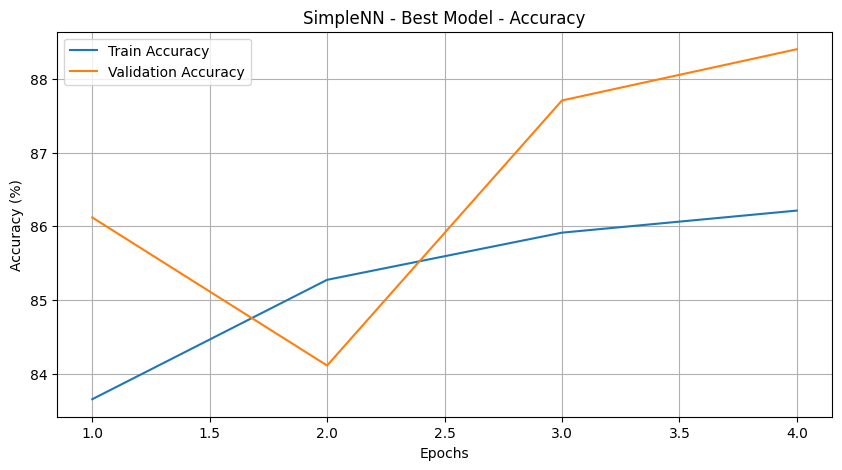

In [11]:
plot_training_history(best_simple["history"], title="SimpleNN - Best Model")

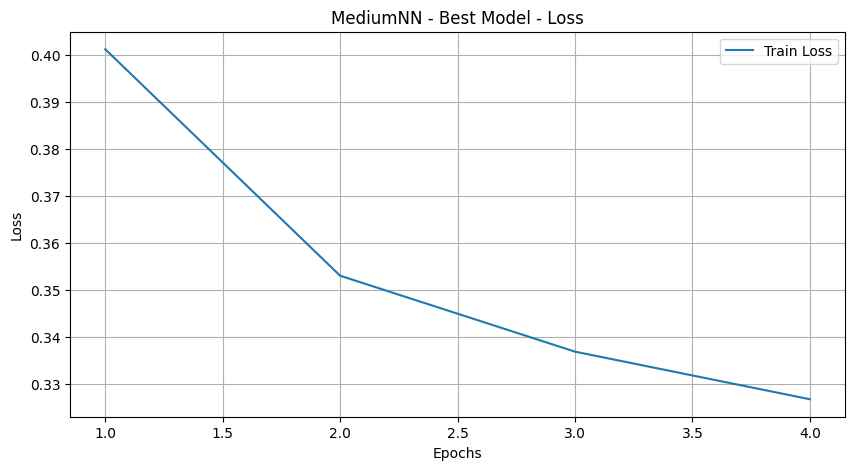

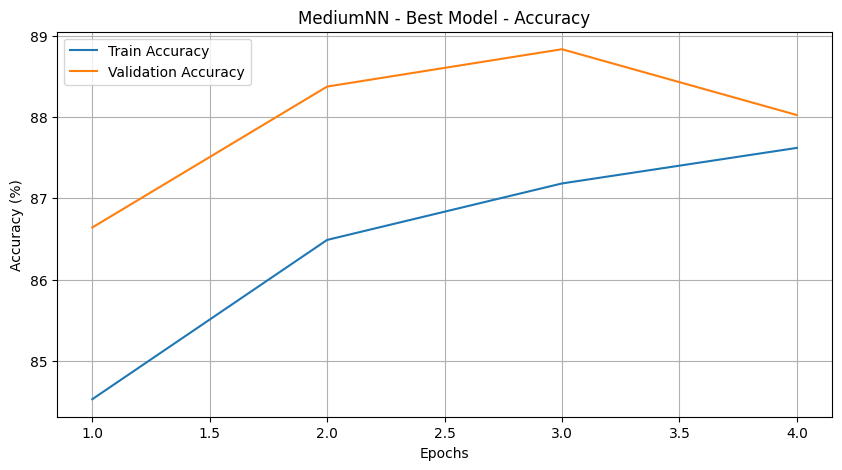

In [12]:
plot_training_history(best_medium["history"], title="MediumNN - Best Model")

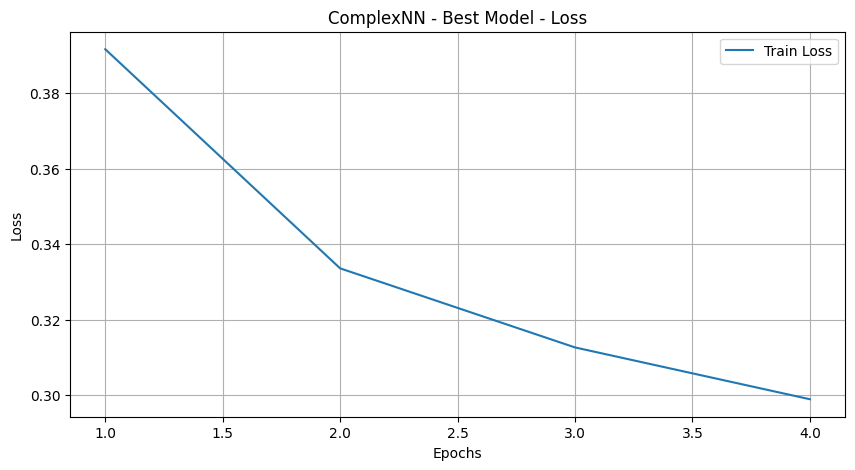

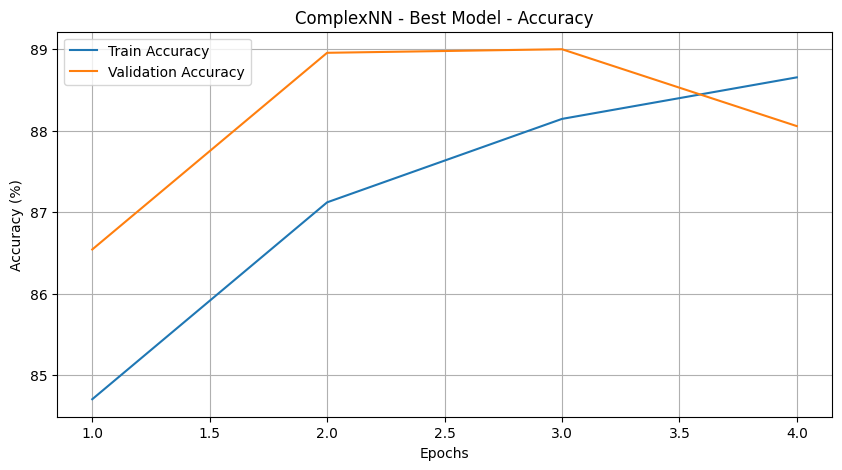

In [13]:
plot_training_history(best_complex["history"], title="ComplexNN - Best Model")

In [14]:
dropout_results = sc.experiments.nn_runner.run_dropout_ablation(
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    input_size=input_size,
    num_classes=num_classes,
    results_df=results_df,
    dropout_values=(0.2, 0.3, 0.5),
    epochs=4,
)



Best configuration for MediumNN: lr=0.01 | val_f1=0.8509

Dropout test → MediumNN | lr=0.01 | dropout=0.2
Epoch 1/4 | loss=0.4468 | train_acc=82.79% | val_acc=87.05%
Epoch 2/4 | loss=0.4057 | train_acc=84.42% | val_acc=87.01%
Epoch 3/4 | loss=0.3944 | train_acc=84.96% | val_acc=87.99%
Epoch 4/4 | loss=0.3902 | train_acc=85.23% | val_acc=88.23%
✔ Done: MediumNN | lr=0.01 | dropout=0.2 | val_f1=0.8470

Dropout test → MediumNN | lr=0.01 | dropout=0.3
Epoch 1/4 | loss=0.4695 | train_acc=82.06% | val_acc=86.30%
Epoch 2/4 | loss=0.4282 | train_acc=83.58% | val_acc=87.30%
Epoch 3/4 | loss=0.4217 | train_acc=84.06% | val_acc=86.78%
Epoch 4/4 | loss=0.4207 | train_acc=84.02% | val_acc=88.13%
✔ Done: MediumNN | lr=0.01 | dropout=0.3 | val_f1=0.8470

Dropout test → MediumNN | lr=0.01 | dropout=0.5
Epoch 1/4 | loss=0.5370 | train_acc=79.88% | val_acc=86.72%
Epoch 2/4 | loss=0.4994 | train_acc=81.19% | val_acc=86.21%
Epoch 3/4 | loss=0.4940 | train_acc=81.51% | val_acc=87.54%
Epoch 4/4 | loss=0.48

In [15]:
dropout_results.sort_values(by="val_f1", ascending=False).head(10)

,model,learning_rate,dropout,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1,history
4,ComplexNN,0.001,0.3,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.347780,86.713661,89.319165,88.234809,0.882900,0.882348,0.881901,89.319165,0.862140,0.867467,0.864206,89.680670,0.866642,0.870010,0.867885,"{'train_loss': [0.4439834803932186, 0.37786382..."
3,ComplexNN,0.001,0.2,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.332645,87.372207,88.278469,87.847308,0.879026,0.878473,0.878240,88.278469,0.849256,0.865278,0.856485,88.765953,0.853971,0.868352,0.860475,"{'train_loss': [0.4242292751528043, 0.36491322..."
5,ComplexNN,0.001,0.5,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.394615,85.139954,88.574245,86.996043,0.871221,0.869960,0.869232,88.574245,0.853737,0.859211,0.854816,88.864545,0.856476,0.862559,0.858097,"{'train_loss': [0.5053003296089078, 0.42089463..."
1,MediumNN,0.010,0.3,MediumNN(\n (net): Sequential(\n (0): Line...,0.420688,84.023827,88.125103,85.563525,0.858528,0.855635,0.854352,88.125103,0.854194,0.843605,0.847041,88.196308,0.854638,0.845174,0.848571,"{'train_loss': [0.46951113804320244, 0.4282159..."
0,MediumNN,0.010,0.2,MediumNN(\n (net): Sequential(\n (0): Line...,0.390228,85.232707,88.234650,86.153022,0.869104,0.861530,0.859912,88.234650,0.858230,0.847611,0.846982,88.305855,0.857488,0.849867,0.847846,"{'train_loss': [0.44682450173085037, 0.4056687..."
2,MediumNN,0.010,0.5,MediumNN(\n (net): Sequential(\n (0): Line...,0.486439,81.825583,87.128225,84.621568,0.850821,0.846216,0.844445,87.128225,0.840325,0.832883,0.833856,87.336364,0.842496,0.835308,0.836177,"{'train_loss': [0.5369701850017435, 0.49942656..."


In [13]:
best_medium_dropout = dropout_results[dropout_results["model"] == "MediumNN"].iloc[0]
best_complex_dropout = dropout_results[dropout_results["model"] == "ComplexNN"].iloc[0]

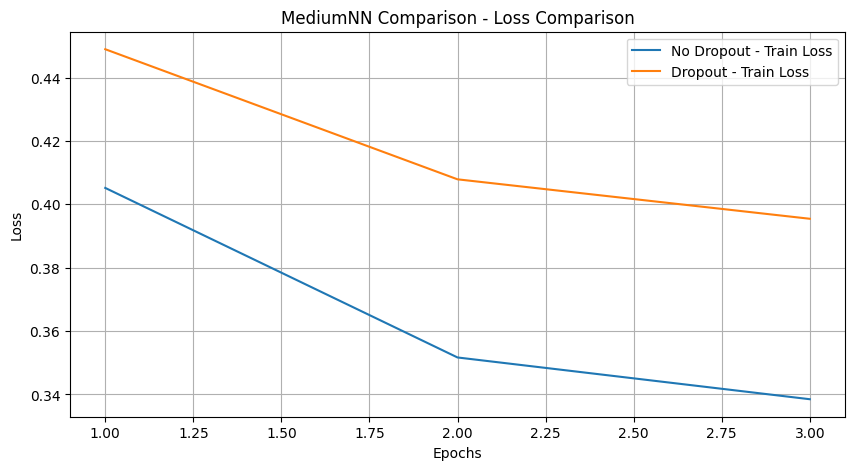

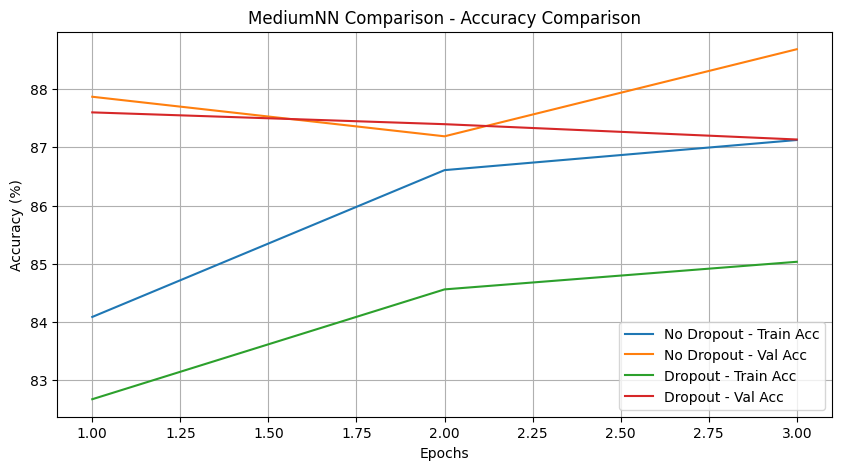

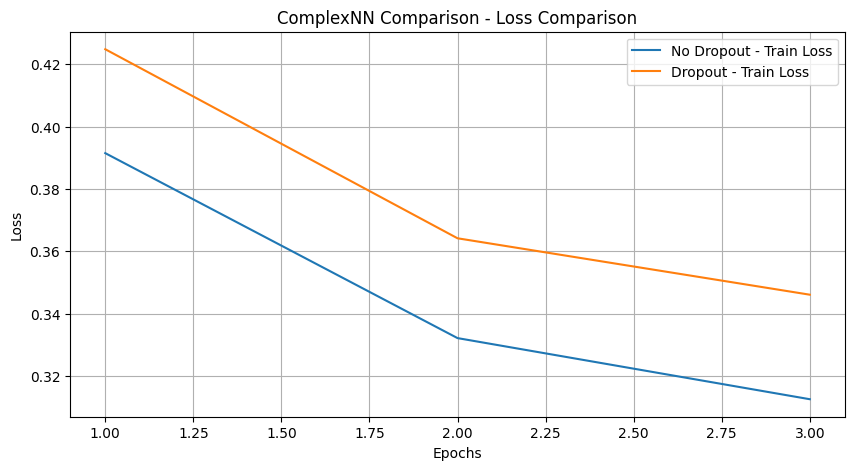

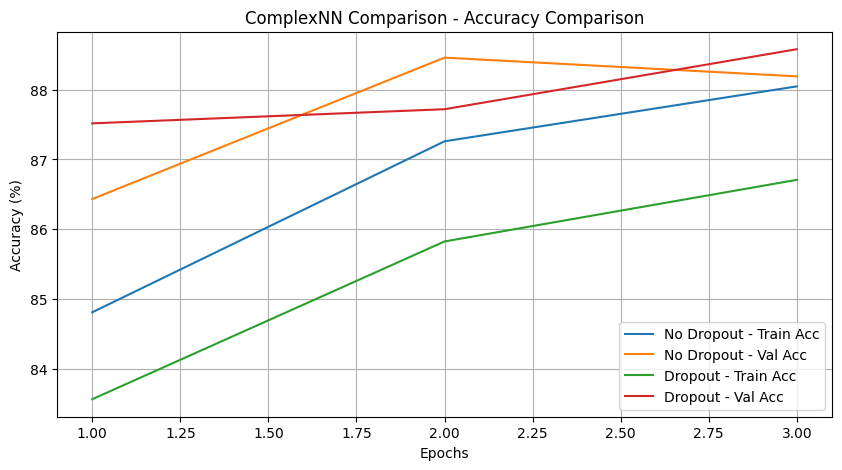

In [14]:
from stellar_classification.visualization.nn_plots import plot_dropout_comparison

plot_dropout_comparison(
    best_medium["history"],
    best_medium_dropout["history"],
    title="MediumNN Comparison"
)

plot_dropout_comparison(
    best_complex["history"],
    best_complex_dropout["history"],
    title="ComplexNN Comparison"
)

In [16]:
from stellar_classification.visualization.model_selection import get_final_candidates

final_sorted = get_final_candidates(
    results_df=results_df,
    dropout_results=dropout_results,
    top_k=3
)

display(final_sorted)

,model,learning_rate,trained_model,final_loss,final_train_acc,final_val_acc,train_accuracy,train_precision,train_recall,train_f1,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1,history,dropout
3,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.347780,86.713661,89.319165,88.234809,0.882900,0.882348,0.881901,89.319165,0.862140,0.867467,0.864206,89.680670,0.866642,0.870010,0.867885,"{'train_loss': [0.4439834803932186, 0.37786382...",0.3
4,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.332645,87.372207,88.278469,87.847308,0.879026,0.878473,0.878240,88.278469,0.849256,0.865278,0.856485,88.765953,0.853971,0.868352,0.860475,"{'train_loss': [0.4242292751528043, 0.36491322...",0.2
5,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.394615,85.139954,88.574245,86.996043,0.871221,0.869960,0.869232,88.574245,0.853737,0.859211,0.854816,88.864545,0.856476,0.862559,0.858097,"{'train_loss': [0.5053003296089078, 0.42089463...",0.5
0,SimpleNN,0.0100,SimpleNN(\n (net): Sequential(\n (0): Line...,0.366887,86.213826,88.404448,86.480749,0.865503,0.864807,0.864172,88.404448,0.852485,0.855969,0.853570,88.453744,0.853156,0.856129,0.854227,"{'train_loss': [0.4342873623654806, 0.39091164...",NaN
1,ComplexNN,0.0010,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.298893,88.651167,88.053897,88.777929,0.887959,0.887779,0.887793,88.053897,0.840788,0.868729,0.853320,88.552336,0.846519,0.871560,0.857910,"{'train_loss': [0.39170132531252205, 0.3335985...",NaN
2,ComplexNN,0.0001,ComplexNN(\n (net): Sequential(\n (0): Lin...,0.332232,87.392819,88.108671,87.506184,0.875627,0.875062,0.874715,88.108671,0.844670,0.861827,0.851700,88.754998,0.852671,0.868399,0.859167,"{'train_loss': [0.4610169898662114, 0.36464433...",NaN



ComplexNN:
  Accuracy  : 89.68%
  Precision: 0.8666
  Recall   : 0.8700
  F1       : 0.8679
  Confusion Matrix:
[[10141   338   302]
 [  255  3038   255]
 [  324   410  3194]]


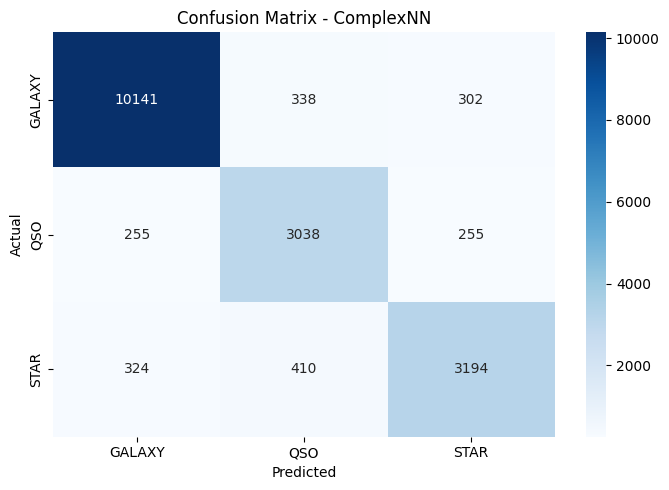

In [17]:
from stellar_classification.experiments.nn_runner import device
from stellar_classification.inference.predictor import evaluate_neural

# Miglior modello assoluto
best_model_row = final_sorted.iloc[0]

best_metrics = evaluate_neural(
    test_loader=test_loader,
    model=best_model_row["trained_model"],
    device=device,
    model_name=f"{best_model_row['model']}"
)

# Stampa metriche
sc.print_metrics(best_metrics)

# Confusion matrix

class_names = list(label_encoder.classes_)

sc.plot_confusion_matrix(
    best_metrics["confusion_matrix"],
    class_names=class_names,
    title=f"Confusion Matrix - {best_model_row['model']}"
)

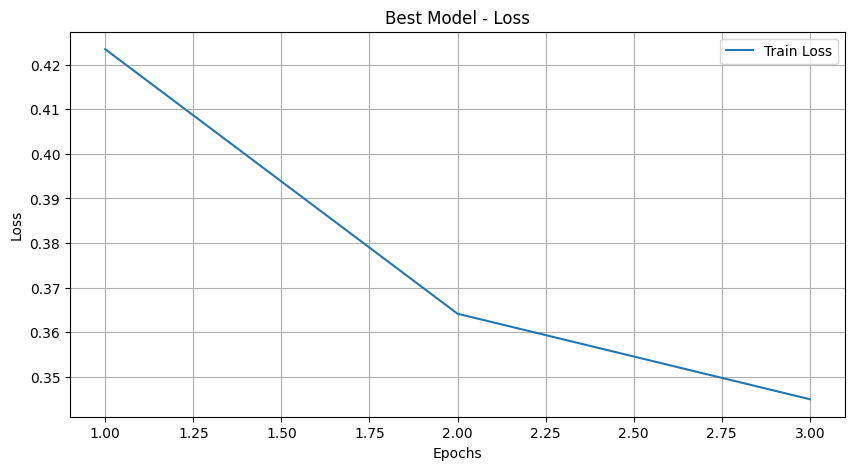

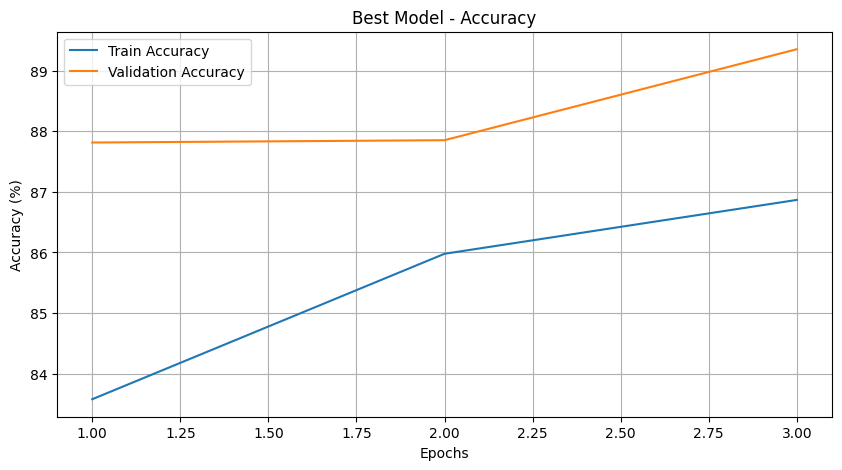

In [17]:
plot_training_history(best_model_row["history"], title="Best Model")

1 batch shape: 4000
2 batch shape: 4000
3 batch shape: 4000
4 batch shape: 4000
5 batch shape: 2257


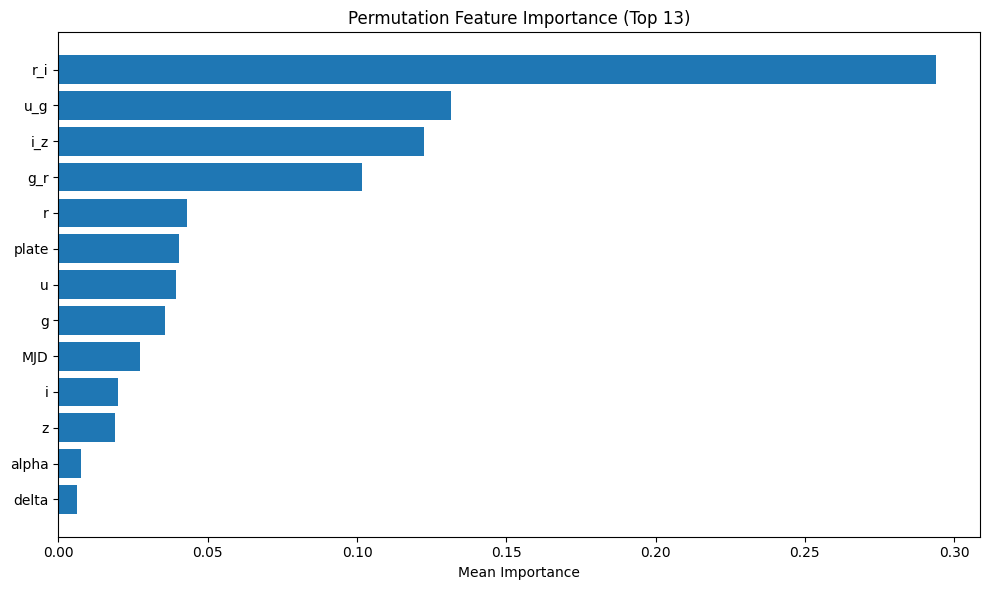

In [18]:
from stellar_classification.utils.wrapper import TorchModelWrapper

from stellar_classification.inference.predictor import compute_permutation_importance


wrapped_model = TorchModelWrapper(best_model_row["trained_model"], device)

imp = compute_permutation_importance(
    wrapped_model,
    X_test,
    y_test,
    feature_names=feature_names,
    n_jobs=1
)

sc.plot_permutation_importance(imp, top_n=13)

In [19]:
from stellar_classification.experiments.feature_ablation import run_feature_ablation

best_model_row = final_sorted.iloc[0]

importance_scores = imp

ablation_results = run_feature_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,
    y_train=y_train,
    y_val=y_val,
    y_test=y_test,
    feature_names=feature_names,
    best_model_row=best_model_row,
    input_size=X_train.shape[1],
    num_classes=num_classes,
    device=device,
    importance_scores=importance_scores,
    epochs=4
)

ablation_results


Best model: ComplexNN | lr=0.001 | dropout=0.3

Training with top-1 features: ['r_i']
Epoch 1/4 | loss=0.8329 | train_acc=59.60% | val_acc=72.94%
Epoch 2/4 | loss=0.8194 | train_acc=61.24% | val_acc=71.36%
Epoch 3/4 | loss=0.8155 | train_acc=61.65% | val_acc=72.17%
Epoch 4/4 | loss=0.8139 | train_acc=61.79% | val_acc=72.65%

Training with top-2 features: ['r_i', 'u_g']
Epoch 1/4 | loss=0.5727 | train_acc=78.35% | val_acc=82.60%
Epoch 2/4 | loss=0.5438 | train_acc=79.68% | val_acc=81.53%
Epoch 3/4 | loss=0.5366 | train_acc=79.92% | val_acc=83.09%
Epoch 4/4 | loss=0.5333 | train_acc=80.10% | val_acc=82.44%

Training with top-3 features: ['r_i', 'u_g', 'i_z']
Epoch 1/4 | loss=0.5234 | train_acc=80.46% | val_acc=83.21%
Epoch 2/4 | loss=0.4844 | train_acc=81.76% | val_acc=82.49%
Epoch 3/4 | loss=0.4762 | train_acc=82.21% | val_acc=84.66%
Epoch 4/4 | loss=0.4714 | train_acc=82.27% | val_acc=83.98%

Training with top-4 features: ['r_i', 'u_g', 'i_z', 'g_r']
Epoch 1/4 | loss=0.4775 | train_ac

,n_features,features,val_f1,test_f1
0,1,[r_i],0.627314,0.629584
1,2,"[r_i, u_g]",0.786057,0.794845
2,3,"[r_i, u_g, i_z]",0.806430,0.809684
3,4,"[r_i, u_g, i_z, g_r]",0.835970,0.840289
4,5,"[r_i, u_g, i_z, g_r, r]",0.857527,0.861526
5,6,"[r_i, u_g, i_z, g_r, r, plate]",0.863562,0.866501
6,7,"[r_i, u_g, i_z, g_r, r, plate, u]",0.865111,0.866199
7,8,"[r_i, u_g, i_z, g_r, r, plate, u, g]",0.861719,0.865023
8,9,"[r_i, u_g, i_z, g_r, r, plate, u, g, MJD]",0.861403,0.864953
9,10,"[r_i, u_g, i_z, g_r, r, plate, u, g, MJD, i]",0.863328,0.866695


In [20]:
print(best_model_row["val_f1"])
print(ablation_results.iloc[-1]["val_f1"])

0.8642060313549988
0.86214212346791


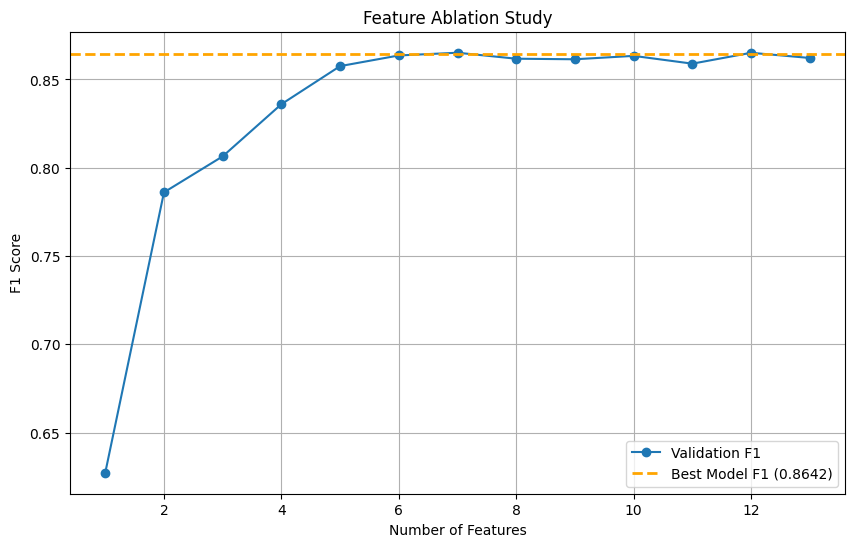

In [21]:
from stellar_classification.visualization.model_selection import plot_feature_ablation

best_val_f1 = final_sorted.iloc[0]["val_f1"]


plot_feature_ablation(
    ablation_results,
    best_val_f1=best_val_f1
)

In [22]:
from stellar_classification.experiments.feature_ablation import (
    get_feature_subset_threshold
)

best_subset = get_feature_subset_threshold(
    ablation_results,
    best_val_f1=best_model_row["val_f1"],
    threshold=0.95,
)

if best_subset is not None:
    print("\n===== 95% FEATURE SUBSET =====")
    print(f"Target F1       : {0.95 * best_model_row['val_f1']:.4f}")
    print(f"Reached F1      : {best_subset['val_f1']:.4f}")
    print(f"N. features     : {best_subset['n_features']}")
    print("\nSelected features:")
    for f in best_subset["features"]:
        print(f" - {f}")
else:
    print("No subset reached the required threshold.")


===== 95% FEATURE SUBSET =====
Target F1       : 0.8210
Reached F1      : 0.8360
N. features     : 4

Selected features:
 - r_i
 - u_g
 - i_z
 - g_r


In [23]:
print(
    f"Relative performance: "
    f"{100 * best_subset['val_f1'] / best_model_row['val_f1']:.2f}%"
)

Relative performance: 96.73%


# PCA

         obj_ID       alpha      delta         u        g         r         i  \
0  1.237661e+18  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573   

          z  run_ID  rerun_ID  ...   spec_obj_ID  class  redshift  plate  \
0  18.79371    3606       301  ...  6.543777e+18      0  0.634794   5812   

     MJD  fiber_ID      u_g      g_r      r_i      i_z  
0  56354       171  1.60352  1.88029  1.22928  0.37202  

[1 rows x 22 columns]
        alpha      delta         u        g         r         i         z  \
0  135.689107  32.494632  23.87882  22.2753  20.39501  19.16573  18.79371   

   class  plate    MJD      u_g      g_r      r_i      i_z  
0      0   5812  56354  1.60352  1.88029  1.22928  0.37202  
Outliers removed: 8,715 rows  (91,285 remain)

PCA ENABLED
Original features: 13
PCA components: 13
Explained variance: 100.00%


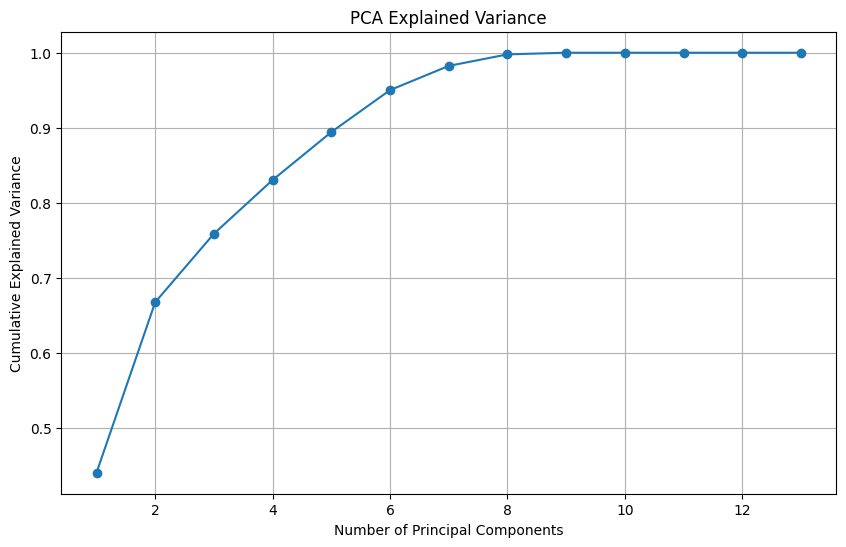

In [24]:
from stellar_classification.data.preprocessing import prepare_splits
from stellar_classification.experiments.pca_ablation import (
    plot_explained_variance
)

# ============================================================
# PCA preprocessing
# ============================================================

(
    X_train_pca,
    X_val_pca,
    X_test_pca,
    y_train_pca,
    y_val_pca,
    y_test_pca,
    label_encoder_pca,
    scaler_pca,
    feature_names_pca,
    pca,
) = prepare_splits(
    star,
    target_col='class',
    test_size=0.2,
    val_ratio=0.25,
    random_state=42,
    apply_outlier_removal=True,

    # PCA
    apply_pca=True,
    n_components=None,
)

# Plot explained variance
plot_explained_variance(pca)

In [25]:
from stellar_classification.experiments.pca_ablation import (
    run_pca_ablation
)

# ============================================================
# Best model
# ============================================================

best_model_row = final_sorted.iloc[0]

# ============================================================
# PCA ablation
# ============================================================

pca_results = run_pca_ablation(
    X_train=X_train,
    X_val=X_val,
    X_test=X_test,

    y_train=y_train,
    y_val=y_val,
    y_test=y_test,

    best_model_row=best_model_row,

    num_classes=num_classes,
    device=device,

    component_list=list(range(1, X_train.shape[1] + 1)),

    epochs=4,
)

display(pca_results)


PCA Experiment | components=1
Explained variance: 41.73%
Epoch 1/4 | loss=0.9880 | train_acc=50.35% | val_acc=44.10%
Epoch 2/4 | loss=0.9763 | train_acc=51.11% | val_acc=34.30%
Epoch 3/4 | loss=0.9714 | train_acc=51.29% | val_acc=35.12%
Epoch 4/4 | loss=0.9695 | train_acc=51.46% | val_acc=37.11%

PCA Experiment | components=2
Explained variance: 65.99%
Epoch 1/4 | loss=0.6831 | train_acc=71.51% | val_acc=78.50%
Epoch 2/4 | loss=0.6583 | train_acc=72.84% | val_acc=78.22%
Epoch 3/4 | loss=0.6519 | train_acc=73.09% | val_acc=78.30%
Epoch 4/4 | loss=0.6480 | train_acc=73.29% | val_acc=77.43%

PCA Experiment | components=3
Explained variance: 75.60%
Epoch 1/4 | loss=0.6755 | train_acc=71.61% | val_acc=78.72%
Epoch 2/4 | loss=0.6423 | train_acc=73.16% | val_acc=75.88%
Epoch 3/4 | loss=0.6313 | train_acc=73.87% | val_acc=79.87%
Epoch 4/4 | loss=0.6254 | train_acc=74.14% | val_acc=78.61%

PCA Experiment | components=4
Explained variance: 83.31%
Epoch 1/4 | loss=0.6443 | train_acc=73.06% | val

,n_components,explained_variance,val_f1,test_f1
0,1,0.417260,0.375526,0.380738
1,2,0.659930,0.719592,0.716302
2,3,0.755961,0.734600,0.729477
3,4,0.833082,0.759038,0.751630
4,5,0.896748,0.787123,0.778057
5,6,0.951347,0.841552,0.843401
6,7,0.984690,0.855655,0.853443
7,8,0.997797,0.864162,0.867873
8,9,1.000000,0.866659,0.867333
9,10,1.000000,0.865370,0.867879


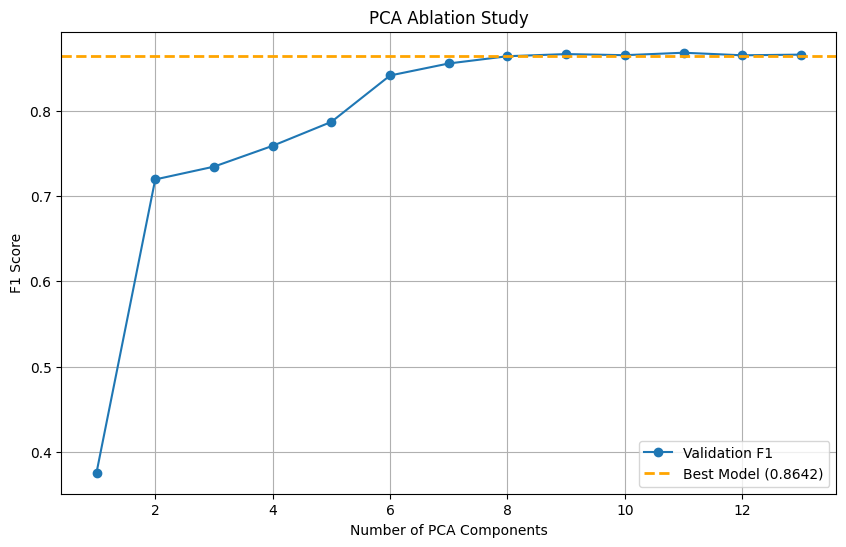

In [26]:
from stellar_classification.visualization.model_selection import (
    plot_pca_ablation
)

plot_pca_ablation(
    pca_results,
    best_val_f1=best_model_row["val_f1"],
)